In [ ]:
import sys
import os
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..", "base")))

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
from jax import jit, random
from functools import partial

jax.config.update("jax_enable_x64", True)

from tools import (
    I, X, Z,
    bracket, antibracket,
    channel_pack,
    run_trajectories_ito
)

In [4]:
@partial(jit, static_argnames=("n_steps",))
def run(rho0, key, n_steps, pack_error, pack_ec, gamma_error, gamma_ec, Omega1, Omega2, dt):
    return run_trajectories_ito(
        rho0, key, n_steps,
        pack_error, pack_ec,
        gamma_error, gamma_ec,
        Omega1, Omega2, dt,
    )

# SB-DB feedback with Luispe's operators (Itô)

In [3]:
# =============================================================================
# FEEDBACK-SPECIFIC: choose dΩ via Omega1 / Omega2 (SBDB example)
# =============================================================================

def build_omega_luispe(PQ, R, A, gammaEC):
    """
    Compute Omega1 and Omega2 in Luispe's feedback scheme.

    Omega2 = i [PQ, R]/2
    Omega1 = -gammaEC/2 * antibracket(A, Omega2)

    Parameters
    ----------
    PQ : array_like (N, N)             # Projector
    R  : array_like (n_ec, N, N)       # e.g., X1, X2, X3
    A  : array_like (n_ec, N, N)       # C4, C5, C6
    gammaEC : array_like (n_ec,)       # feedback rates

    Returns
    -------
    Omega1, Omega2 : each (n_ec, N, N)
    """
    n_ec = R.shape[0]
    PQ_rep = jnp.broadcast_to(PQ, (n_ec, PQ.shape[-2], PQ.shape[-1]))
    # [PQ, R]
    Omega2 = 1j * bracket(PQ_rep, R) / 2.0

    # Fix: gammaEC has shape (n_ec,), antibracket(A, Omega2) has (n_ec, N, N)
    # Need to reshape gammaEC so it broadcasts correctly
    Omega1 = -gammaEC[:, None, None] / 2.0 * antibracket(A, Omega2)

    return Omega1, Omega2


In [8]:
# =============================================================================
# OPERATORS / SETUP
# =============================================================================

n = 3
N = 2**n

T = 10.0
L = 1000
dt = T / L
n_traj = 50

gamma_error = 0e-3 * jnp.array([1.0, 1.0, 1.0], dtype=jnp.float64)
gamma_ec = 1 * jnp.array([1.0, 1.0, 1.0], dtype=jnp.float64)

X1 = jnp.kron(jnp.kron(X, I), I)
X2 = jnp.kron(jnp.kron(I, X), I)
X3 = jnp.kron(jnp.kron(I, I), X)

e000 = jnp.zeros((N), dtype=jnp.complex128).at[0].set(1.0)
e111 = jnp.zeros((N), dtype=jnp.complex128).at[-1].set(1.0)
PQ = e000[:, None] * jnp.conj(e000)[None, :] + e111[:, None] * jnp.conj(e111)[None, :]

C_error = jnp.stack([X1, X2, X3], axis=0)

lamb = 1.

C4 = 0.5 * antibracket(PQ, X1) + lamb * X1 @ PQ @ X1
C5 = 0.5 * antibracket(PQ, X2) + lamb * X2 @ PQ @ X2
C6 = 0.5 * antibracket(PQ, X3) + lamb * X3 @ PQ @ X3
C_ec = jnp.stack([C4, C5, C6], axis=0)

pack_error = channel_pack(C_error)
pack_ec = channel_pack(C_ec)

# Omega1, Omega2 = build_omega_sbdb(
#     pack_ec["A"], pack_ec["B"], PQ, gamma_ec
# )

Omega1, Omega2 = build_omega_luispe(PQ, C_error, C_ec, gamma_ec)

# Omega1 = jnp.zeros_like(pack_ec["A"])
# Omega2 = jnp.zeros_like(pack_ec["A"])

q = e000
Q = q[:, None] @ jnp.conj(q)[None, :]

var = 1e-2  # example variance, adjust as needed
noise = jax.random.normal(random.PRNGKey(42), q.shape, dtype=q.dtype) * jnp.sqrt(var)
psi0 = q + noise
psi0 = psi0 / jnp.linalg.norm(psi0)
P0 = psi0[:, None] * jnp.conj(psi0)[None, :]
rho0 = jnp.broadcast_to(P0[None, :, :], (n_traj, N, N))


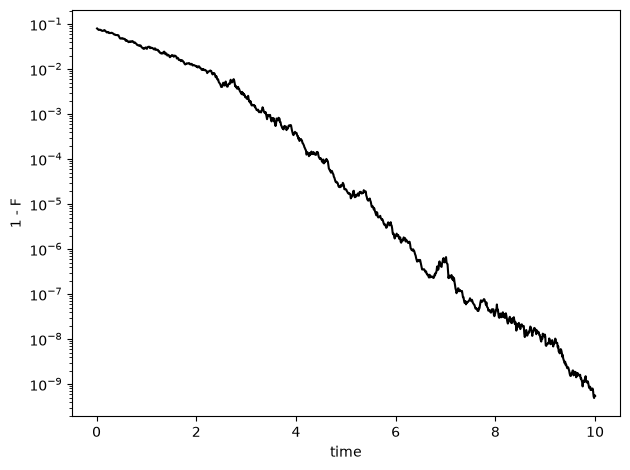

In [9]:
key = random.PRNGKey(0)
rho_all = run(rho0, key, L, pack_error, pack_ec, gamma_error, gamma_ec, Omega1, Omega2, dt)
rho_all.block_until_ready()

F_all = jnp.real(jnp.einsum("stij,ji->st", rho_all, PQ))

times = dt * jnp.arange(1, L + 1)
mean_F = jnp.mean(F_all, axis=1)

plt.figure(2)
plt.semilogy(times, 1.0 - jnp.abs(mean_F), "k")
plt.xlabel("time")
plt.ylabel("1 - F")
plt.tight_layout()
plt.show()


In [ ]:
float(jnp.max(jnp.abs(1 - mean_F)))

0.0

# $TS$-rotation feedback

In [4]:
del run

In [12]:
# =============================================================================
# FEEDBACK-SPECIFIC: choose dΩ via Omega1 / Omega2 (SBDB example)
# =============================================================================


# def build_omega_STrotation(A, B, gamma):
#     """
#     ST-rotation feedback: set Omegas from
#         dΩ_t = (π/2) dH^S_SB
#     where
#         dH^S_SB = -i (γ/2) {A, B} dt + i B dY_t

#     A, B: (n_ec, N, N), PQ: (N, N), gamma: (n_ec,)
#     Returns Omega1, Omega2 each (n_ec, N, N).
#     """
#     g = jnp.asarray(gamma, dtype=A.real.dtype)[:, None, None]
#     anticomAB = antibracket(A, B)

#     gamma_fb = 1

#     # Omega1 multiplies dt, Omega2 multiplies dY_t
#     Omega1 = gamma_fb * (-1j * (g / 2.0) * anticomAB)
#     Omega2 = gamma_fb * (1j * B)
#     return Omega1, Omega2

def build_omega_STrotation():
    # Omega1 is set to 0 (no dt feedback here)
    Omega1 = jnp.zeros((2, N, N), dtype=complex)
    # Omega2 is a stack of two operators, each (N,N):
    # First: i * Z1Z2 * (X1/2), Second: i * Z2Z3 * (X2/2)
    O2_1 = 1j * Z1Z2 @ (X1 / 2)
    O2_2 = 1j * Z2Z3 @ (X3 / 2)
    gamma_fb = 1
    Omega2 = gamma_fb * jnp.stack([O2_1, O2_2], axis=0)
    return Omega1, Omega2

# =============================================================================
# OPERATORS / SETUP
# =============================================================================

n = 3
N = 2**n

T = 10.0
L = 1000
dt = T / L
n_traj = 50

gamma_error = 1e-3 * jnp.array([1.0, 1.0, 1.0], dtype=jnp.float64)
gamma_ec = 1 * jnp.array([1.0, 1.0], dtype=jnp.float64)

X1 = jnp.kron(jnp.kron(X, I), I)
X2 = jnp.kron(jnp.kron(I, X), I)
X3 = jnp.kron(jnp.kron(I, I), X)

Id = jnp.eye(8, dtype=jnp.float64)

Z1Z2 = jnp.kron(jnp.kron(Z, Z), I)
Z2Z3 = jnp.kron(jnp.kron(I, Z), Z)

e000 = jnp.zeros((N), dtype=jnp.complex128).at[0].set(1.0)
e111 = jnp.zeros((N), dtype=jnp.complex128).at[-1].set(1.0)
PQ = e000[:, None] * jnp.conj(e000)[None, :] + e111[:, None] * jnp.conj(e111)[None, :]

C_error = jnp.stack([X1, X2, X3], axis=0)

C4 = X1/2
C5 = X3/2
C_ec = jnp.stack([C4, C5], axis=0)

pack_error = channel_pack(C_error)
pack_ec = channel_pack(C_ec)

Omega1, Omega2 = build_omega_STrotation()
# Omega1 = jnp.zeros((2, N, N), dtype=complex)
# Omega2 = jnp.zeros((2, N, N), dtype=complex)


q = e000
Q = q[:, None] @ jnp.conj(q)[None, :]

var = 0e-2  # example variance, adjust as needed
noise = jax.random.normal(random.PRNGKey(42), q.shape, dtype=q.dtype) * jnp.sqrt(var)
psi0 = q + noise
psi0 = psi0 / jnp.linalg.norm(psi0)
P0 = psi0[:, None] * jnp.conj(psi0)[None, :]
rho0 = jnp.broadcast_to(P0[None, :, :], (n_traj, N, N))

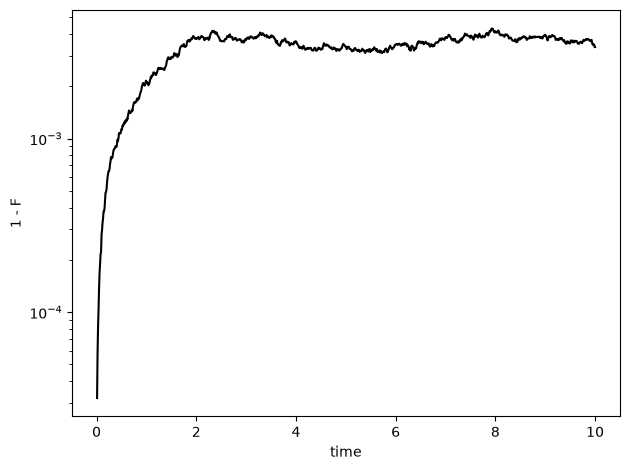

In [13]:
key = random.PRNGKey(0)
rho_all = run(rho0, key, L, pack_error, pack_ec, gamma_error, gamma_ec, Omega1, Omega2, dt)
rho_all.block_until_ready()

F_all = jnp.real(jnp.einsum("stij,ji->st", rho_all, PQ))

times = dt * jnp.arange(1, L + 1)
mean_F = jnp.mean(F_all, axis=1)

plt.figure(2)
plt.semilogy(times, 1.0 - jnp.abs(mean_F), "k")
plt.xlabel("time")
plt.ylabel("1 - F")
plt.tight_layout()
plt.show()


In [14]:
float(jnp.max(jnp.abs(mean_F)))

0.9999679778986266